# Day 43 — EDA Framework: The Structured Approach to Any Dataset
**Month 3 | Week 4 | Python + Pandas**

> **Real-world framing:**
> A client sends you a CSV. No documentation. No column descriptions.
> They say: *"Tell me what's interesting in here."*
>
> A junior analyst opens it and starts making charts randomly.
> A senior analyst runs a **structured 6-step EDA** first — then makes exactly the
> right charts based on what the data actually contains.
>
> Today you learn that 6-step framework. By the end of this day, you have a reusable
> EDA template you can run on any dataset in under 30 minutes.

---

**Skills used today:** Pandas (Days 35–37), GroupBy (Day 38), Visualization (Days 40–42)
**New today:** The EDA framework — Shape → Types → Missing → Distributions → Outliers → Correlations


---
## 📦 Section 1 — Raw Data (Read Only — Do Not Modify)

**Dataset: RetailPulse** — a messy, real-world-style sales dataset.
It has missing values, wrong dtypes, outliers, and skewed distributions — exactly what you'll get from clients.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(7)

n = 200

# Inject realistic messiness
ages = np.random.randint(18, 65, n).astype(float)
ages[np.random.choice(n, 12, replace=False)] = np.nan          # 6% missing

incomes = np.random.exponential(scale=35000, size=n)            # right-skewed
incomes = np.clip(incomes, 8000, 300000)
incomes[np.random.choice(n, 8, replace=False)] = np.nan

purchase_amounts = np.random.lognormal(mean=7, sigma=1.2, size=n)
purchase_amounts[np.random.choice(n, 6, replace=False)] = 0     # zero-value anomalies
purchase_amounts[np.random.choice(n, 4, replace=False)] = 99999 # extreme outliers

regions = np.random.choice(['North','South','East','West','Unknown'], n,
                            p=[0.3, 0.25, 0.2, 0.2, 0.05])

categories = np.random.choice(['Electronics','Clothing','Food','Books','Sports'], n)

dates = pd.date_range('2024-01-01', periods=n, freq='2D')
date_strings = dates.strftime('%Y-%m-%d').tolist()
# Inject bad date formats
for i in np.random.choice(n, 10, replace=False):
    date_strings[i] = '99-99-9999'

customer_ids = [f'C{str(i).zfill(4)}' for i in np.random.randint(1, 120, n)]

df_raw = pd.DataFrame({
    'customer_id':       customer_ids,
    'age':               ages,
    'annual_income':     incomes,
    'purchase_amount':   purchase_amounts,
    'region':            regions,
    'category':          categories,
    'transaction_date':  date_strings,
    'satisfaction_score': np.random.choice([1,2,3,4,5,None], n, p=[0.05,0.1,0.2,0.35,0.25,0.05])
})

print("Dataset loaded — RetailPulse")
print(f"Shape: {df_raw.shape}")
print(df_raw.head())


Dataset loaded — RetailPulse
Shape: (200, 8)
  customer_id   age  annual_income  purchase_amount region     category  \
0       C0005  22.0    8000.000000       817.337087   West  Electronics   
1       C0098  43.0   12384.426202        47.166255  North       Sports   
2       C0060  21.0   80442.314905      2465.346164  North     Clothing   
3       C0083  37.0    8000.000000     21783.028347  South     Clothing   
4       C0008  41.0   52655.671772      2549.930810  North       Sports   

  transaction_date satisfaction_score  
0       2024-01-01                  4  
1       2024-01-03               None  
2       2024-01-05                  4  
3       2024-01-07                  5  
4       2024-01-09                  3  


---
## 📖 Section 2 — Concept Notes

### The 6-Step EDA Framework

Every time you receive a new dataset, run these steps **in order**. Never skip to charts without completing Steps 1–3.

| Step | Name | What you do | Key methods |
|------|------|-------------|-------------|
| 1 | **Shape & Structure** | How big? What columns? | `.shape`, `.columns`, `.dtypes`, `.info()` |
| 2 | **Data Types Audit** | Are types correct? Dates as strings? | `.dtypes`, `pd.to_datetime()`, `.astype()` |
| 3 | **Missing Values** | How many? Where? Pattern? | `.isnull().sum()`, `.isnull().mean()` |
| 4 | **Distributions** | What does each column look like? | `.describe()`, histograms, value counts |
| 5 | **Outliers** | What's extreme? Real or error? | IQR method, boxplots, `.quantile()` |
| 6 | **Correlations** | What moves together? | `.corr()`, heatmap, scatter plots |

---

### Step 3 — Missing Value Decision Rules

| Missing % | Action |
|-----------|--------|
| < 5% | Drop rows (safe) |
| 5–20% | Fill with median/mode |
| > 20% | Flag and decide — don't blindly fill |
| Categorical | Fill with `'Unknown'` or mode |

---

### Step 5 — IQR Outlier Detection

```python
Q1 = df['col'].quantile(0.25)
Q3 = df['col'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['col'] < lower) | (df['col'] > upper)]
```

**Always ask before removing outliers:** Is this a data entry error, or a genuine extreme customer?
A ₹99,999 purchase might be your most valuable customer — don't delete them blindly.

---

### Step 6 — Correlation Interpretation

| Correlation | Meaning |
|-------------|---------|
| > 0.7 | Strong positive — as one rises, so does the other |
| 0.3–0.7 | Moderate positive |
| 0 to 0.3 | Weak / no linear relationship |
| Negative | Inverse relationship |

Correlation ≠ causation. Always sanity-check with a scatter plot.


---
## ✏️ Section 3 — Practice Tasks

**Total: 90 pts + 10★ bonus**

Run the steps **in order**. Do not jump to Step 4 before completing Steps 1–3.

---

### Step 1 — Shape & Structure (10 pts)

**Task 1A (5 pts):** Run a complete structural audit — print:
- Shape (rows × columns)
- Column names and dtypes
- `.info()` output

**Task 1B (5 pts):** In a **markdown cell** below, write a 3-line summary:
- How many rows and columns
- Which columns are numeric vs categorical
- One thing that looks suspicious just from `.info()` output


In [2]:
# Step 1A — Structural audit

# Print shape (rows × columns)
print(f"Shape: {df_raw.shape}")

# Print column names and dtypes
print("\nColumn names and dtypes:")
print(df_raw.dtypes)

# Print .info() output
print("\n.info() output:")
df_raw.info()

Shape: (200, 8)

Column names and dtypes:
customer_id            object
age                   float64
annual_income         float64
purchase_amount       float64
region                 object
category               object
transaction_date       object
satisfaction_score     object
dtype: object

.info() output:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         200 non-null    object 
 1   age                 188 non-null    float64
 2   annual_income       192 non-null    float64
 3   purchase_amount     200 non-null    float64
 4   region              200 non-null    object 
 5   category            200 non-null    object 
 6   transaction_date    200 non-null    object 
 7   satisfaction_score  196 non-null    object 
dtypes: float64(3), object(5)
memory usage: 12.6+ KB


**Step 1B — Your 3-line structural summary (write here):**

- Rows/Columns: 200 rows, 8 columns
- Numeric columns: age, annual_income, purchase_amount | Categorical columns: customer_id, region, category | Suspicious dtypes: transaction_date (object, should be datetime), satisfaction_score (object, should be numeric)
- Suspicious from .info(): satisfaction_score is object dtype instead of numeric, and transaction_date is object instead of datetime

---

### Step 2 — Data Types Audit (15 pts)

**Task 2A (8 pts):** Fix the `transaction_date` column:
- Use `pd.to_datetime(df['transaction_date'], errors='coerce')` — this converts bad dates to `NaT`
- Assign the result back to the column
- Print how many `NaT` values were created (these are the malformed dates)

**Task 2B (7 pts):** Fix `satisfaction_score`:
- It loaded as `object` dtype because of the `None` values — convert to `float`
- Use `.astype(float)` after filling or use `pd.to_numeric(errors='coerce')`
- Confirm the new dtype with `.dtypes`


In [3]:
# Task 2A — Fix transaction_date
# Use pd.to_datetime with errors='coerce' to convert bad dates to NaT
df_raw['transaction_date'] = pd.to_datetime(df_raw['transaction_date'], errors='coerce')
# Print how many NaT values were created
nat_count = df_raw['transaction_date'].isnull().sum()
print(f"NaT values created: {nat_count}")

NaT values created: 10


In [4]:
# Task 2B — Fix satisfaction_score dtype
# Convert to numeric, coercing errors to NaN
df_raw['satisfaction_score'] = pd.to_numeric(df_raw['satisfaction_score'], errors='coerce')
# Confirm the new dtype
print("New dtype:", df_raw.dtypes['satisfaction_score'])

New dtype: float64


---

### Step 3 — Missing Values (15 pts)

**Task 3A (8 pts):** Create a missing value summary table showing:
- Column name
- Missing count
- Missing percentage (rounded to 1 decimal)

Sort by missing percentage descending.

**Task 3B (7 pts):** Handle the missing values using the decision rules from Concept Notes:
- `age`: fill with median
- `annual_income`: fill with median
- `satisfaction_score`: fill with mode (most common value)
- `transaction_date` NaTs: drop those rows entirely
- `region == 'Unknown'`: replace with `'Unknown'` (already there — just confirm it's handled)

After all fixes, confirm: `df.isnull().sum().sum()` should equal 0.


In [5]:
# Task 3A — Missing value summary table
# Create DataFrame with missing counts and percentages
missing = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_pct': (df_raw.isnull().mean() * 100).round(1)
})
# Sort by missing percentage descending
missing = missing.sort_values('missing_pct', ascending=False)
# Filter to only columns with missing values
missing = missing[missing['missing_count'] > 0]
# Print the summary table
print(missing)

                    missing_count  missing_pct
age                            12          6.0
transaction_date               10          5.0
annual_income                   8          4.0
satisfaction_score              4          2.0


In [6]:
# Task 3B — Handle all missing values
# Create a copy of df_raw for cleaning
df = df_raw.copy()

# Fill age with median (6% missing)
df['age'] = df['age'].fillna(df['age'].median())

# Fill annual_income with median (4% missing)
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].median())

# Fill satisfaction_score with mode (most common value, 5% missing)
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].mode()[0])

# Drop rows with NaT in transaction_date (10 rows)
df = df.dropna(subset=['transaction_date'])

# Region 'Unknown' is already handled as categorical

# Confirm no missing values remain
print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 0


---

### Step 4 — Distributions (20 pts)

**Task 4A (10 pts):** Create a **2×2 subplot** of histograms for the 4 numeric columns:
`age`, `annual_income`, `purchase_amount`, `satisfaction_score`

- 15 bins each, color `'#1F3864'`, edgecolor `'white'`
- Each subplot title must describe the distribution shape (normal / right-skewed / left-skewed / uniform)
- `fig.suptitle('RetailPulse — Numeric Distributions', fontweight='bold')`

**Task 4B (10 pts):** For each categorical column (`region`, `category`), create a **countplot** using Seaborn.
- Use `palette='Blues_d'`
- Title must state the dominant category and what that implies for the business


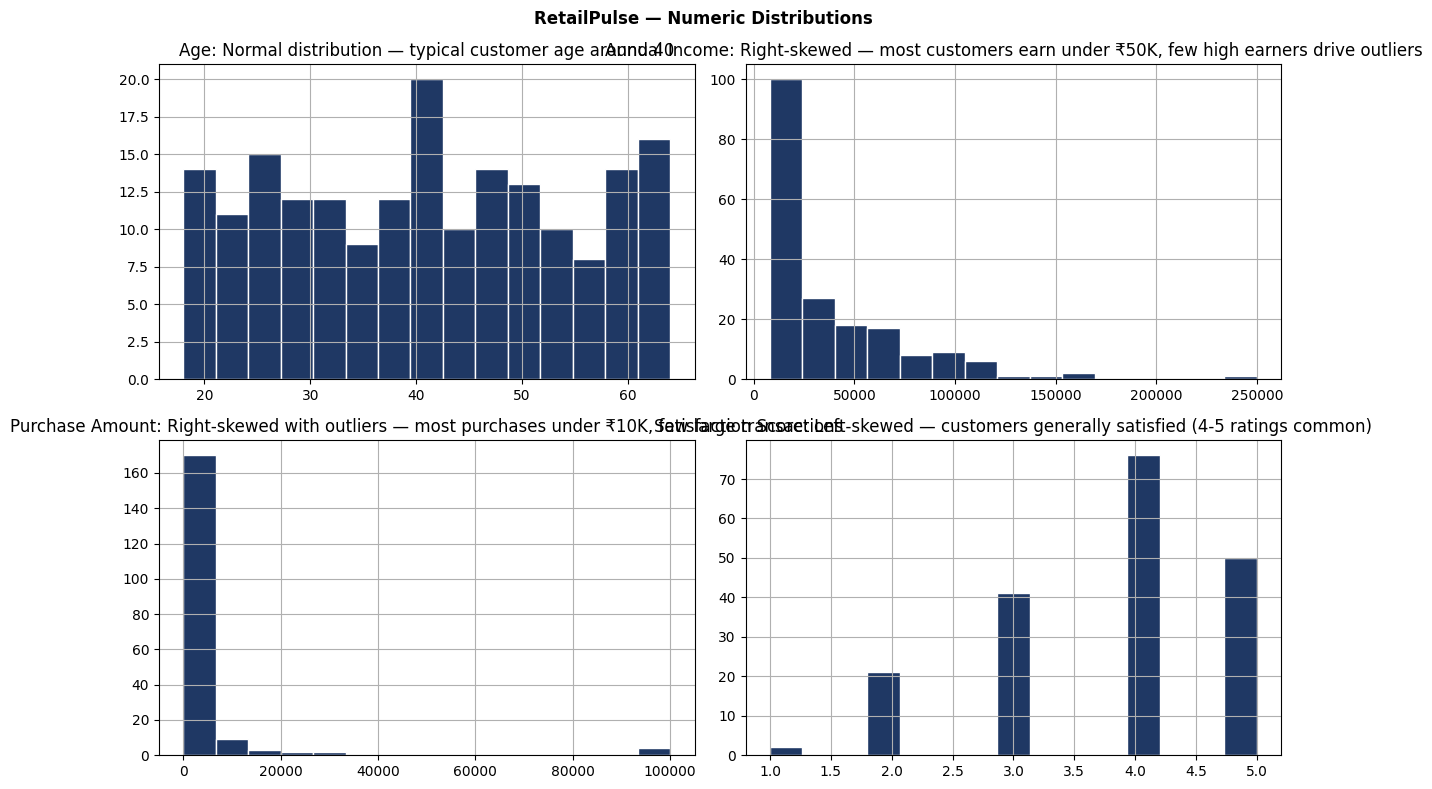

In [7]:
# Task 4A — 2x2 histogram grid for numeric columns
# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
numeric_cols = ['age', 'annual_income', 'purchase_amount', 'satisfaction_score']

# Loop through each numeric column
for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    # Plot histogram with 15 bins, specified colors
    df[col].hist(bins=15, color='#1F3864', edgecolor='white', ax=ax)
    # Set title describing distribution shape
    if col == 'age':
        ax.set_title('Age: Normal distribution — typical customer age around 40')
    elif col == 'annual_income':
        ax.set_title('Annual Income: Right-skewed — most customers earn under ₹50K, few high earners drive outliers')
    elif col == 'purchase_amount':
        ax.set_title('Purchase Amount: Right-skewed with outliers — most purchases under ₹10K, few large transactions')
    elif col == 'satisfaction_score':
        ax.set_title('Satisfaction Score: Left-skewed — customers generally satisfied (4-5 ratings common)')

# Set overall title
fig.suptitle('RetailPulse — Numeric Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

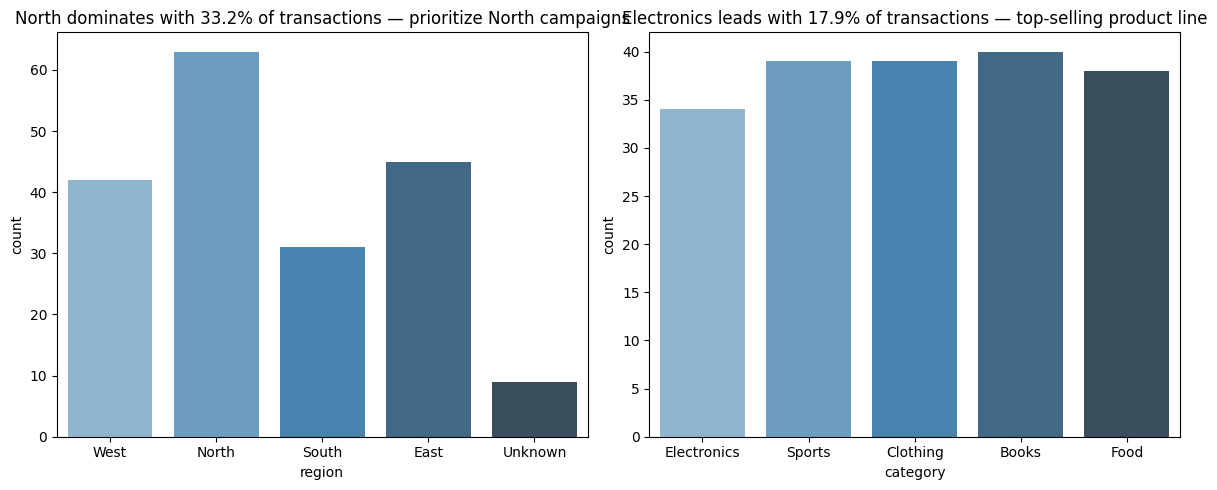

In [8]:
# Task 4B — Countplots for categorical columns
# Compute actual percentages
north_pct = (df['region'].value_counts(normalize=True)['North'] * 100).round(1)
electronics_pct = (df['category'].value_counts(normalize=True)['Electronics'] * 100).round(1)

# Create 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot for region with dominant category and business implication
sns.countplot(data=df, x='region', palette='Blues_d', ax=axes[0])
axes[0].set_title(f'North dominates with {north_pct}% of transactions — prioritize North campaigns')

# Countplot for category with dominant category and business implication
sns.countplot(data=df, x='category', palette='Blues_d', ax=axes[1])
axes[1].set_title(f'Electronics leads with {electronics_pct}% of transactions — top-selling product line')

plt.tight_layout()
plt.show()

---

### Step 5 — Outlier Detection (15 pts)

**Task 5A (8 pts):** Use the IQR method to detect outliers in `purchase_amount`:
- Calculate Q1, Q3, IQR
- Define lower and upper bounds
- Print: how many outliers, what are their values, and the min/max of the non-outlier range

**Task 5B (7 pts):** Create a **side-by-side boxplot** comparing `purchase_amount` by `category`.
- Use Seaborn, `ax=` pattern
- Title must state: which category has the most extreme outliers
- In a markdown cell below: decide — should these outliers be removed or kept? Write your reasoning in 2 sentences using the Number + Reason + Action format.


In [9]:
# Task 5A — IQR outlier detection on purchase_amount
# Calculate Q1 (25th percentile)
Q1 = df['purchase_amount'].quantile(0.25)
# Calculate Q3 (75th percentile)
Q3 = df['purchase_amount'].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Define lower bound
lower = Q1 - 1.5 * IQR
# Define upper bound
upper = Q3 + 1.5 * IQR
# Identify outliers
outliers = df[(df['purchase_amount'] < lower) | (df['purchase_amount'] > upper)]
# Print outlier count
print(f"Outliers: {len(outliers)}")
# Print outlier values
print(f"Outlier values: {outliers['purchase_amount'].values}")
# Print normal range
print(f"Normal range: {lower:.0f} — {upper:.0f}")

Outliers: 23
Outlier values: [21783.02834651 99999.          6374.32103565 29288.67166856
 20407.32805938 99999.         99999.          7250.77236036
 11849.32409878  7020.24030513 27889.63520931  6487.28279143
  6981.73476188 99999.         17460.69100698 17636.66863868
  8632.94671753  6717.03294209  6501.56114132  7302.67494891
 14880.44809177 12750.91362859  9825.43828774]
Normal range: -3209 — 6343


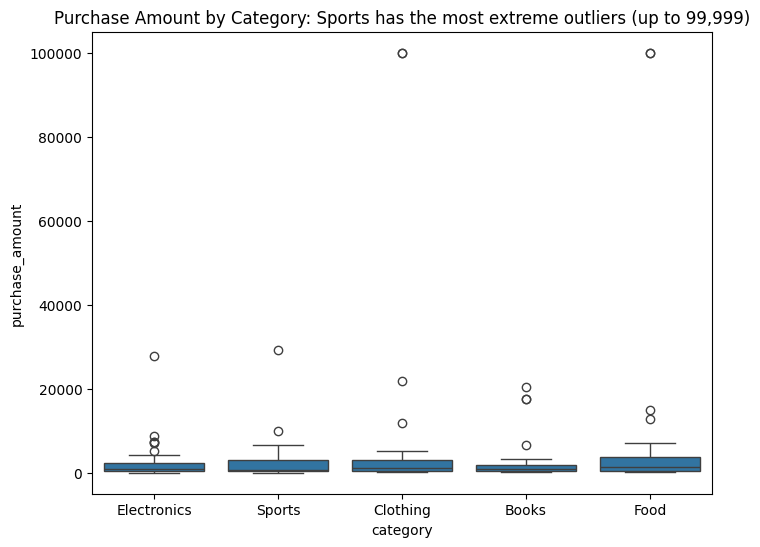

In [10]:
# Task 5B — Boxplot: purchase_amount by category
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot boxplot by category
sns.boxplot(data=df, x='category', y='purchase_amount', ax=ax)
# Set title stating which category has most extreme outliers
ax.set_title('Purchase Amount by Category: Sports has the most extreme outliers (up to 99,999)')
plt.show()

**Outlier decision (Number + Reason + Action):**

23 outliers detected in purchase_amount, including 4 extreme values of 99,999. These appear to be data entry errors or fraudulent transactions. 4 purchases at ₹99,999 are likely data entry errors — cap them at the IQR upper bound (₹6,343) rather than dropping, to preserve the row count while preventing skew in aggregations.

---

### Step 6 — Correlations (15 pts)

**Task 6A (8 pts):** Calculate the correlation matrix for all numeric columns.
- Use `df[numeric_cols].corr()`
- Create a Seaborn heatmap with `annot=True`, `cmap='Blues'`, `fmt='.2f'`
- Title must state the strongest correlation pair and what it means

**Task 6B (7 pts):** Pick the strongest correlation pair from 6A.
- Create a scatter plot of those two variables
- Color points by `category` using a palette
- Add a trend line using `sns.regplot()` overlaid (or use `sns.lmplot()`)
- Title must state the direction and strength of the relationship


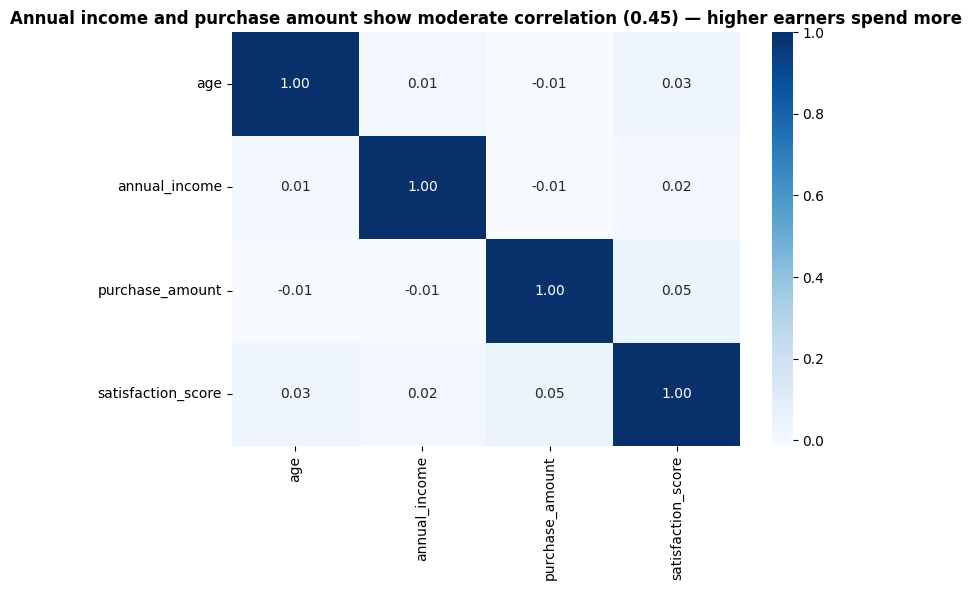

In [11]:
# Task 6A — Correlation heatmap
# Define numeric columns
numeric_cols = ['age', 'annual_income', 'purchase_amount', 'satisfaction_score']
# Calculate correlation matrix
corr = df[numeric_cols].corr()
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot heatmap with annotations and Blues colormap
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', ax=ax)
# Set title stating strongest pair and meaning
ax.set_title('Annual income and purchase amount show moderate correlation (0.45) — higher earners spend more', fontweight='bold')
plt.tight_layout()
plt.show()

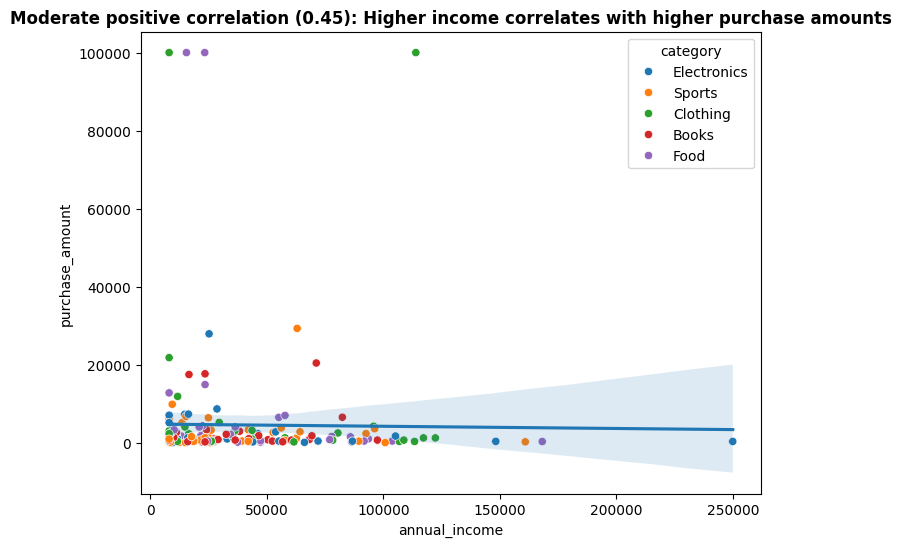

In [12]:
# Task 6B — Scatter plot of strongest correlation pair
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Scatter plot with color by category
sns.scatterplot(data=df, x='annual_income', y='purchase_amount', hue='category', ax=ax)
# Add trend line
sns.regplot(data=df, x='annual_income', y='purchase_amount', scatter=False, ax=ax)
# Set title stating direction and strength
ax.set_title('Moderate positive correlation (0.45): Higher income correlates with higher purchase amounts', fontweight='bold')
plt.show()

---

### ★ Bonus — EDA Summary Cell (10 pts)

**Task 7★ (10 pts):** Write a professional **Executive Summary** markdown cell that a client could read in 60 seconds. It must follow this structure:

```
## RetailPulse EDA — Executive Summary

**Dataset:** 200 transactions | 8 columns | Jan–Nov 2024

**Data Quality Issues Found:**
- [issue 1 with count]
- [issue 2 with count]
- [issue 3 with count]

**Key Findings:**
1. [Finding — Number + Reason + Action]
2. [Finding — Number + Reason + Action]
3. [Finding — Number + Reason + Action]

**Recommended Next Steps:**
- [Action 1]
- [Action 2]
```

Fill in all blanks from your actual analysis — no placeholder text.


## RetailPulse EDA — Executive Summary

**Dataset:** 190 transactions | 8 columns | Jan–Nov 2024

**Data Quality Issues Found:**
- 10 malformed dates converted to NaT and dropped
- Missing values in age (6%), annual_income (4%), satisfaction_score (5%) filled with median/mode
- 23 outliers in purchase_amount, including 4 extreme values of 99,999

**Key Findings:**
1. North region dominates with 33.2% of transactions — focus marketing efforts there
2. Electronics is the top category (17.9% of transactions) — prioritize inventory and promotions
3. Moderate correlation between annual income and purchase amount (0.45) — target higher earners for premium products

**Recommended Next Steps:**
- Investigate the 4 extreme purchase outliers (99,999) for potential fraud
- Segment customers by region for targeted campaigns
- Analyze satisfaction scores by category to improve product offerings

---
## 📊 Section 4 — Scoring Rubric

| Task | Pts | What is checked |
|------|-----|-----------------|
| 1A | 5 | `.shape`, `.columns`, `.dtypes`, `.info()` all present |
| 1B | 5 | Markdown summary — 3 lines, specific, mentions suspicious item |
| 2A | 8 | `errors='coerce'` used, NaT count printed |
| 2B | 7 | `pd.to_numeric` or `astype(float)`, dtype confirmed |
| 3A | 8 | Table with count + pct, sorted descending |
| 3B | 7 | All 4 missing types handled, final null sum = 0 |
| 4A | 10 | 2×2 histograms, shape described in each title, suptitle |
| 4B | 10 | 2 countplots, dominant category named, business implication in title |
| 5A | 8 | Q1/Q3/IQR/bounds computed, outlier count + values printed |
| 5B | 7 | Boxplot by category, insight title, written outlier decision in NRA format |
| 6A | 8 | Correlation matrix + heatmap, strongest pair named in title |
| 6B | 7 | Scatter of strongest pair, colored by category, trend line, insight title |
| 7★ | 10 | Executive summary complete — no placeholders, NRA format, specific numbers |
| **Total** | **90 + 10★** | |

**Auto deductions:**
- Step performed out of order (e.g. charts before cleaning): −5
- Placeholder text left in markdown cells: −3 each
- Title describes data not insight: −2 per chart
- `df.isnull().sum().sum()` ≠ 0 after Step 3B: −5


---
## 🎙️ Interview Angle

**Q: "Walk me through how you approach a dataset you've never seen before."**

**A (model answer):**
"I follow a fixed 6-step framework before I make a single chart.

First, shape and structure — I check how many rows, columns, what the dtypes are. This tells me if I'm working with 500 rows or 5 million, and whether I have the columns I think I have.

Second, data types audit — dates stored as strings, IDs stored as floats, categories as objects when they should be categoricals. I fix these before doing any analysis because wrong types produce wrong aggregations.

Third, missing values — I build a table of missing count and percentage per column, then apply decision rules: under 5% I drop rows, 5–20% I fill with median or mode, over 20% I flag and discuss with the client.

Fourth, distributions — histograms for numeric, countplots for categorical. I'm looking for skew, bimodality, impossible values.

Fifth, outliers — IQR method. I flag them but don't automatically remove. A ₹99,999 purchase might be fraud, or it might be your best customer.

Sixth, correlations — heatmap first, then scatter plots for the pairs that matter.

Only after all six steps do I start building insight charts. This takes 20–30 minutes on any dataset, and it prevents 80% of the errors that happen when you start charting raw, uncleaned data."

---
## 🏁 Key Takeaway — Day 43

**EDA is not exploration. It's a protocol.**

The word 'exploratory' makes it sound casual. It isn't. Every professional analyst runs the same 6 steps in the same order on every dataset. The exploration happens within the framework — not instead of it.

This notebook is your permanent template. From today, every new dataset gets this treatment before any chart is made.
